In [1]:
# e-greedy constant step size

import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from NonstationaryBandit import * # Ensure this is in the same directory

# Parameters
params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 100000
n = 10
num_runs = 100
step_size = 0.1

# 2. Prepare the list of tasks (Cartesian product of runs and params)
# Each task is a tuple of arguments for the simulate_bandit function
tasks = []
for eps_val in params:
    for _ in range(num_runs):
        tasks.append((init_bandit_ns, n, eps_val, num_steps, step_size))

print(f"Starting {len(tasks)} simulations across {multiprocessing.cpu_count()} cores...")

# 3. Use a Pool to run simulations in parallel
with multiprocessing.Pool() as pool:
    # starmap allows passing multiple arguments to the function
    results = pool.starmap(run_ns_bandit_cnst_step, tasks)

print("Simulations complete. Aggregating results...")

# 4. Reshape and aggregate the results
# results is a list of 1000 tuples: [(rewards, optimal), (rewards, optimal), ...]
# We split them into two arrays
all_rewards = np.array([res[0] for res in results]) # Shape: (1000, 200000)
all_optimal = np.array([res[1] for res in results])

# Reshape to (num_params, num_runs, num_steps) to easily average over runs
all_rewards = all_rewards.reshape(len(params), num_runs, num_steps)
all_optimal = all_optimal.reshape(len(params), num_runs, num_steps)

# Calculate the average across the 100 runs (axis 1)
avg_rewards_cnst_stp = np.mean(all_rewards, axis=1)
avg_optimal_cnst_stp = np.mean(all_optimal, axis=1)

# 5. Calculate final summary metric (mean of the second half of steps)
avg_last_rewards_cnst_stp_params = np.mean(avg_rewards_cnst_stp[:, int(0.5*num_steps):], axis=1)

print("Success! Final summary rewards per parameter:")
print(avg_last_rewards_cnst_stp_params)
# plt.plot(avg_rewards_cnst_stp[5,::10])

Starting 1000 simulations across 32 cores...
Simulations complete. Aggregating results...
Success! Final summary rewards per parameter:
[4.00243854 4.48138999 3.9349918  3.80719055 4.17585465 3.26049545
 2.3103373  0.20796428 0.0605895  0.13724259]


In [2]:
# e-greedy average

import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from NonstationaryBandit import * # Ensure this is in the same directory

# Parameters
params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 100000
n = 10
num_runs = 100
step_size = 0.1

# 2. Prepare the list of tasks (Cartesian product of runs and params)
# Each task is a tuple of arguments for the simulate_bandit function
tasks = []
for eps_val in params:
    for _ in range(num_runs):
        tasks.append((init_bandit_ns, n, eps_val, num_steps))

print(f"Starting {len(tasks)} simulations across {multiprocessing.cpu_count()} cores...")

# 3. Use a Pool to run simulations in parallel
with multiprocessing.Pool() as pool:
    # starmap allows passing multiple arguments to the function
    results = pool.starmap(run_ns_greedy_bandit_sample_avg, tasks)

print("Simulations complete. Aggregating results...")

# 4. Reshape and aggregate the results
# results is a list of 1000 tuples: [(rewards, optimal), (rewards, optimal), ...]
# We split them into two arrays
all_rewards = np.array([res[0] for res in results]) # Shape: (1000, 200000)
all_optimal = np.array([res[1] for res in results])

# Reshape to (num_params, num_runs, num_steps) to easily average over runs
all_rewards = all_rewards.reshape(len(params), num_runs, num_steps)
all_optimal = all_optimal.reshape(len(params), num_runs, num_steps)

# Calculate the average across the 100 runs (axis 1)
avg_rewards_smp_avg = np.mean(all_rewards, axis=1)
avg_optimal_smp_avg = np.mean(all_optimal, axis=1)

# 5. Calculate final summary metric (mean of the second half of steps)
avg_last_rewards_smp_avg_params = np.mean(avg_rewards_smp_avg[:, int(0.5*num_steps):], axis=1)

print("Success! Final summary rewards per parameter:")
print(avg_last_rewards_smp_avg_params)
# plt.plot(avg_rewards_smp_avg[5,::10])

Starting 1000 simulations across 32 cores...
Simulations complete. Aggregating results...
Success! Final summary rewards per parameter:
[2.89273374 3.28205938 3.28617335 3.26159107 3.12158655 2.40006865
 1.77786645 0.13362996 0.08620436 0.08111359]


In [3]:

# e-greedy unbiased step size

import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from NonstationaryBandit import * # Ensure this is in the same directory

# Parameters
params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 100000
n = 10
num_runs = 100
eps = 0.1

# 2. Prepare the list of tasks (Cartesian product of runs and params)
# Each task is a tuple of arguments for the simulate_bandit function
tasks = []
for stepsize in params[:7]:
    for _ in range(num_runs):
        tasks.append((init_bandit_ns, n, eps, num_steps, stepsize))

print(f"Starting {len(tasks)} simulations across {multiprocessing.cpu_count()} cores...")

# 3. Use a Pool to run simulations in parallel
with multiprocessing.Pool() as pool:
    # starmap allows passing multiple arguments to the function
    results = pool.starmap(run_ns_greedy_unbiased_step_size, tasks)

print("Simulations complete. Aggregating results...")

# 4. Reshape and aggregate the results
# results is a list of 1000 tuples: [(rewards, optimal), (rewards, optimal), ...]
# We split them into two arrays
all_rewards = np.array([res[0] for res in results]) # Shape: (1000, 200000)
all_optimal = np.array([res[1] for res in results])

# Reshape to (num_params, num_runs, num_steps) to easily average over runs
all_rewards = all_rewards.reshape(len(params[:7]), num_runs, num_steps)
all_optimal = all_optimal.reshape(len(params[:7]), num_runs, num_steps)

# Calculate the average across the 100 runs (axis 1)
avg_rewards_unb = np.mean(all_rewards, axis=1)
avg_optimal_unb = np.mean(all_optimal, axis=1)

# 5. Calculate final summary metric (mean of the second half of steps)
avg_last_rewards_unb_params = np.mean(avg_rewards_unb[:, int(0.5*num_steps):], axis=1)

print("Success! Final summary rewards per parameter:")
print(avg_last_rewards_unb_params)
# plt.plot(avg_rewards_cnst_stp[5,::10])

Starting 700 simulations across 32 cores...
Simulations complete. Aggregating results...
Success! Final summary rewards per parameter:
[3.63809503 3.79242593 3.56047665 3.68033973 3.91946405 3.93784032
 3.7684982 ]


In [4]:
# UCB bandit


import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from NonstationaryBandit import * # Ensure this is in the same directory

# Parameters
params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 100000
n = 10
num_runs = 100
step_size = 0.1

# 2. Prepare the list of tasks (Cartesian product of runs and params)
# Each task is a tuple of arguments for the simulate_bandit function
tasks = []
for c in params:
    for _ in range(num_runs):
        tasks.append((init_bandit_ns, n, c, num_steps))

print(f"Starting {len(tasks)} simulations across {multiprocessing.cpu_count()} cores...")

# 3. Use a Pool to run simulations in parallel
with multiprocessing.Pool() as pool:
    # starmap allows passing multiple arguments to the function
    results = pool.starmap(run_ns_UCB_bandit_sample_avg, tasks)

print("Simulations complete. Aggregating results...")

# 4. Reshape and aggregate the results
# results is a list of 1000 tuples: [(rewards, optimal), (rewards, optimal), ...]
# We split them into two arrays
all_rewards = np.array([res[0] for res in results]) # Shape: (1000, 200000)
all_optimal = np.array([res[1] for res in results])

# Reshape to (num_params, num_runs, num_steps) to easily average over runs
all_rewards = all_rewards.reshape(len(params), num_runs, num_steps)
all_optimal = all_optimal.reshape(len(params), num_runs, num_steps)

# Calculate the average across the 100 runs (axis 1)
avg_rewards_ucb = np.mean(all_rewards, axis=1)
avg_optimal_ucb = np.mean(all_optimal, axis=1)

# 5. Calculate final summary metric (mean of the second half of steps)
avg_last_rewards_ucb_params = np.mean(avg_rewards_ucb[:, int(0.5*num_steps):], axis=1)

print("Success! Final summary rewards per parameter:")
print(avg_last_rewards_ucb_params)

Starting 1000 simulations across 32 cores...
Simulations complete. Aggregating results...
Success! Final summary rewards per parameter:
[1.84248922 1.85219732 1.86683946 1.82409066 2.02793351 2.67145919
 2.17487587 2.10087615 2.75931758 2.89844739]


In [5]:
# gradient bandit

import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from NonstationaryBandit import * # Ensure this is in the same directory

# Parameters
params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 100000
n = 10
num_runs = 100
step_size = 0.1

# 2. Prepare the list of tasks (Cartesian product of runs and params)
# Each task is a tuple of arguments for the simulate_bandit function
tasks = []
for alpha in params:
    for _ in range(num_runs):
        tasks.append((init_bandit_ns, n, alpha, num_steps))

print(f"Starting {len(tasks)} simulations across {multiprocessing.cpu_count()} cores...")

# 3. Use a Pool to run simulations in parallel
with multiprocessing.Pool() as pool:
    # starmap allows passing multiple arguments to the function
    results = pool.starmap(run_ns_Gradient_bandit, tasks)

print("Simulations complete. Aggregating results...")

# 4. Reshape and aggregate the results
# results is a list of 1000 tuples: [(rewards, optimal), (rewards, optimal), ...]
# We split them into two arrays
all_rewards = np.array([res[0] for res in results]) # Shape: (1000, 200000)
all_optimal = np.array([res[1] for res in results])

# Reshape to (num_params, num_runs, num_steps) to easily average over runs
all_rewards = all_rewards.reshape(len(params), num_runs, num_steps)
all_optimal = all_optimal.reshape(len(params), num_runs, num_steps)

# Calculate the average across the 100 runs (axis 1)
avg_rewards_grad = np.mean(all_rewards, axis=1)
avg_optimal_grad = np.mean(all_optimal, axis=1)

# 5. Calculate final summary metric (mean of the second half of steps)
avg_last_rewards_grad_params = np.mean(avg_rewards_grad[:, int(0.5*num_steps):], axis=1)

print("Success! Final summary rewards per parameter:")
print(avg_last_rewards_grad_params)


Starting 1000 simulations across 32 cores...
Simulations complete. Aggregating results...
Success! Final summary rewards per parameter:
[2.70056303 2.75102303 2.53496005 2.39831507 2.51281489 2.09673053
 1.89893841 1.85849284 1.65714197 0.74688082]


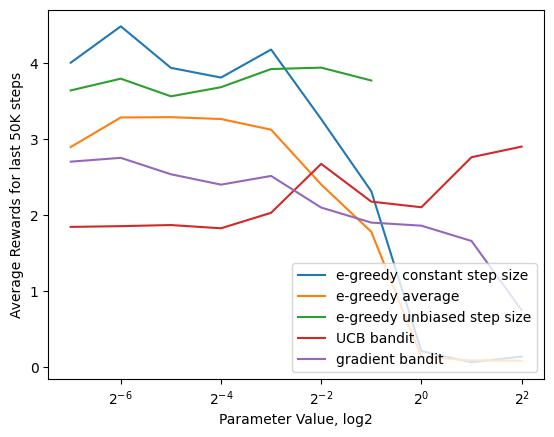

In [ ]:
# plotting
plt.plot(params, avg_last_rewards_cnst_stp_params, label="e-greedy constant step size")
plt.plot(params, avg_last_rewards_smp_avg_params, label="e-greedy average")
plt.plot(params[:7], avg_last_rewards_unb_params, label="e-greedy unbiased step size")
plt.plot(params, avg_last_rewards_ucb_params, label = 'UCB bandit')
plt.plot(params, avg_last_rewards_grad_params, label="gradient bandit")
plt.xscale('log', base=2)
plt.xlabel('Parameter Value, log2')
plt.ylabel('Average Rewards for last 50K steps')
plt.title('Parameter Study, 2.11')
plt.legend(loc="lower right")
plt.show()

